# Regression Analysis – Auto MPG Dataset

In this part of the project we analyze a supervised regression problem
using the Auto MPG dataset. The goal is to predict a car's fuel efficiency
(measured in miles per gallon – mpg) based on several vehicle characteristics
such as weight, horsepower, and number of cylinders.

We begin with an exploratory data analysis (EDA) to understand the structure
of the dataset, examine the distribution of the target variable, and explore
relationships between the features and the target.


## Import Libraries


In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Load Dataset

In [31]:
url = "http://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data"

columns = [
    "mpg",
    "cylinders",
    "displacement",
    "horsepower",
    "weight",
    "acceleration",
    "model_year",
    "origin",
    "car_name"
]

df = pd.read_csv(url, delim_whitespace=True, names=columns, na_values="?") ##missing values as ?

df.head()

/tmp/ipykernel_287/499590778.py:15: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(url, delim_whitespace=True, names=columns, na_values="?") ##missing values as ?


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car_name
0,18.0,8,307.0,130.0,3504.0,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693.0,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436.0,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433.0,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449.0,10.5,70,1,ford torino


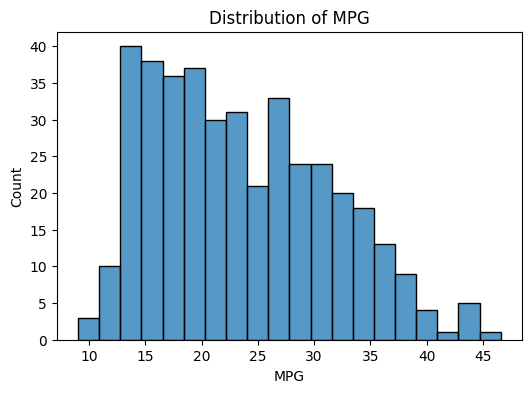

In [32]:
plt.figure(figsize=(6,4))
sns.histplot(df["mpg"], bins=20)
plt.title("Distribution of MPG")
plt.xlabel("MPG")
plt.ylabel("Count")
plt.show()

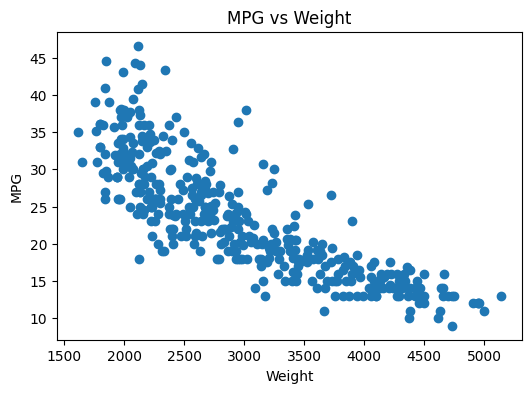

In [33]:
plt.figure(figsize=(6,4))
plt.scatter(df["weight"], df["mpg"])
plt.title("MPG vs Weight")
plt.xlabel("Weight")
plt.ylabel("MPG")
plt.show()

### Relationship between Weight and MPG

The scatter plot shows a negative relationship between vehicle weight
and fuel efficiency. As the weight of the car increases, the mpg values
generally decrease. This makes sense since heavier vehicles typically
consume more fuel.This suggests that weight is likely an important feature
for predicting mpg.

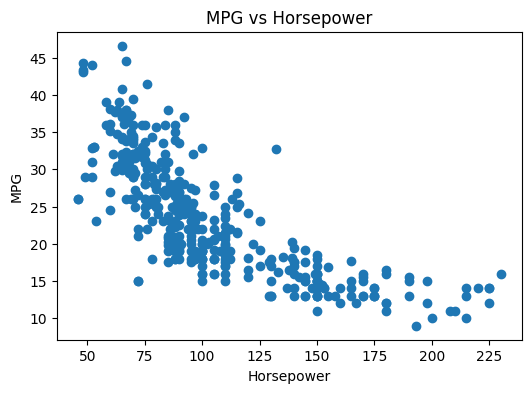

In [34]:
plt.figure(figsize=(6,4))

plt.scatter(df["horsepower"], df["mpg"])

plt.title("MPG vs Horsepower")
plt.xlabel("Horsepower")
plt.ylabel("MPG")

plt.show()

The scatter plot indicates a negative relationship between horsepower and mpg.
As horsepower increases, fuel efficiency generally decreases.

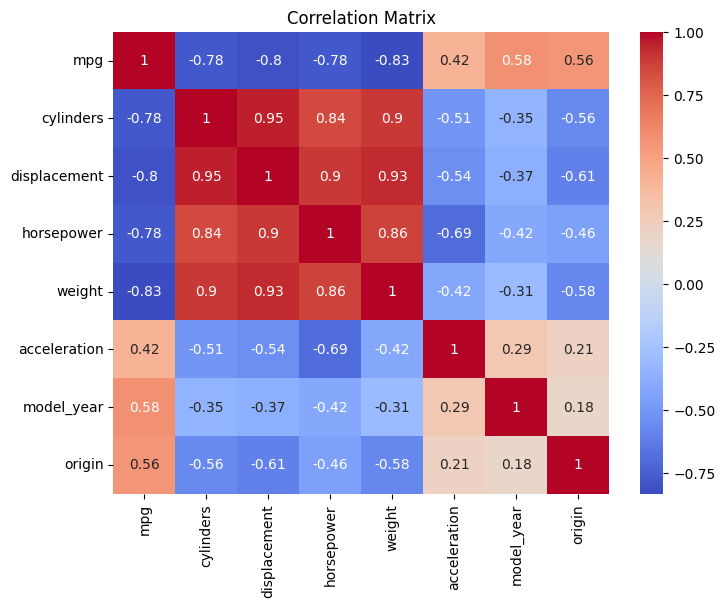

In [35]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm") ##calculate only for numbers to find corelation
plt.title("Correlation Matrix")
plt.show()

### Correlation Analysis

The correlation matrix shows the relationships between the variables.
We observe strong negative correlations between mpg and variables such
as weight, horsepower, and cylinders. This suggests that heavier cars
and cars with more powerful engines tend to have lower fuel efficiency.

In [36]:
df.isnull().sum() ##finding missing values

,0
mpg,0
cylinders,0
displacement,0
horsepower,6
weight,0
acceleration,0
model_year,0
origin,0
car_name,0


In [37]:
df["horsepower"] = df["horsepower"].fillna(df["horsepower"].median()) ##if there is missing values replace it with median


In [38]:
df.isnull().sum() ##finding missing values after ths change

,0
mpg,0
cylinders,0
displacement,0
horsepower,0
weight,0
acceleration,0
model_year,0
origin,0
car_name,0


### Handling Missing Values

The "horsepower" column contains 6 missing values.  
These values were replaced with the median of the column.

# preprocessing

In [39]:
X = df.drop(["mpg", "car_name"], axis=1)  ## we use the features excקpt the name feture,only numbers
y = df["mpg"]                             ## the target

In [40]:
## we devide to train and test before reching the models
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [41]:
## Standardization for forward model-KNN. we do that because the range variables is diffrent
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Data Preprocessing

The dataset was split into training and testing sets using an 80/20 split.
The numerical features were standardized using StandardScaler so that each
feature has a mean of 0 and a standard deviation of 1.
Standardization is important for models such as KNN that rely on distance
calculations.

## Linear Regression Baseline


we begin with the simplest reasonable approach to the problem - Linear Regression.

In [42]:
from sklearn.linear_model import LinearRegression ## training linear regression model

linear_model = LinearRegression()

linear_model.fit(X_train_scaled, y_train)

LinearRegression()

In [43]:
y_pred_linear = linear_model.predict(X_test_scaled) ##data prediction

In [44]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score  ##calculate MSE,RMSE,MAE,R^2
import numpy as np

mse = mean_squared_error(y_test, y_pred_linear)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred_linear)
r2 = r2_score(y_test, y_pred_linear)

print("MSE:", mse)
print("RMSE:", rmse)
print("MAE:", mae)
print("R2:", r2)

MSE: 8.197746885824964
RMSE: 2.8631707748272657
MAE: 2.2553632612835637
R2: 0.8475304239212407


### Linear Regression Performance

The performance of the linear regression model was evaluated using several
metrics: MSE, RMSE, MAE, and R².

The results show that the model achieves an R² score of approximately 0.85,
indicating that it explains most of the variance in the target variable (mpg).
The RMSE and MAE values suggest that the model's predictions differ from the
true mpg values by about 2–3 mpg on average.

## Prediction vs Ground Truth

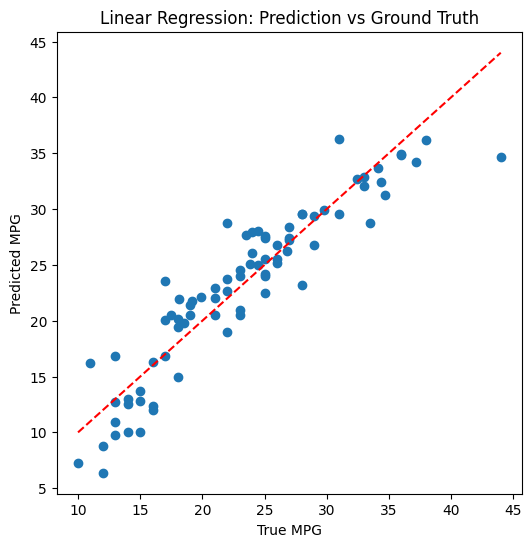

In [45]:
 ## plot of prediction vs groung truth
plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred_linear)

plt.xlabel("True MPG")
plt.ylabel("Predicted MPG")

plt.title("Linear Regression: Prediction vs Ground Truth")

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--')

plt.show()

The red line says that: Prediction = True value .

The scatter plot compares the predicted mpg values with the true mpg values
from the test set. Most points lie close to the diagonal reference line,
indicating that the linear regression model captures the general relationship
between the features and fuel efficiency. Some deviations from the line
are still visible, suggesting that the model does not perfectly explain all
variability in the data.

## Polynomial Regression and Model Complexity

In this section, we increase the flexibility of the regression model by
introducing polynomial features. We train models with different polynomial
degrees and select the best degree based on validation performance.

In [46]:
from sklearn.model_selection import train_test_split ## train\validation\test

X = df.drop(["mpg", "car_name"], axis=1)
y = df["mpg"]

# split into temporary train set and final test set
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# split temporary train set into train and validation
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42
)

In [47]:
from sklearn.preprocessing import StandardScaler ## standrdization

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [48]:
degrees = [1, 2, 3, 4, 5] ##select degree check

In [49]:
## training modek acording to diffrent degrees
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import numpy as np

train_errors = []
val_errors = []

for degree in degrees:
    poly = PolynomialFeatures(degree=degree)

    X_train_poly = poly.fit_transform(X_train_scaled)
    X_val_poly = poly.transform(X_val_scaled)

    model = LinearRegression()
    model.fit(X_train_poly, y_train)

    y_train_pred = model.predict(X_train_poly)
    y_val_pred = model.predict(X_val_poly)

    train_mse = mean_squared_error(y_train, y_train_pred)
    val_mse = mean_squared_error(y_val, y_val_pred)

    train_errors.append(train_mse)
    val_errors.append(val_mse)

    print(f"Degree {degree}: Train MSE = {train_mse:.4f}, Validation MSE = {val_mse:.4f}")

Degree 1: Train MSE = 10.6108, Validation MSE = 15.1897
Degree 2: Train MSE = 5.2787, Validation MSE = 13.2955
Degree 3: Train MSE = 2.2657, Validation MSE = 141.9051
Degree 4: Train MSE = 0.0000, Validation MSE = 845.3354
Degree 5: Train MSE = 0.0000, Validation MSE = 1421.5958


In [50]:
## choosing best degree for the model
best_degree = degrees[np.argmin(val_errors)]
print("Best degree based on validation error:", best_degree)

Best degree based on validation error: 2


### Degree Selection

We trained polynomial regression models with degrees from 1 to 5 and
evaluated their training and validation errors.

While the training error decreases as the polynomial degree increases,
the validation error is lowest for degree 2 and increases dramatically
for higher degrees. This indicates overfitting for high-degree models.

Therefore, degree 2 was selected as the best polynomial model.

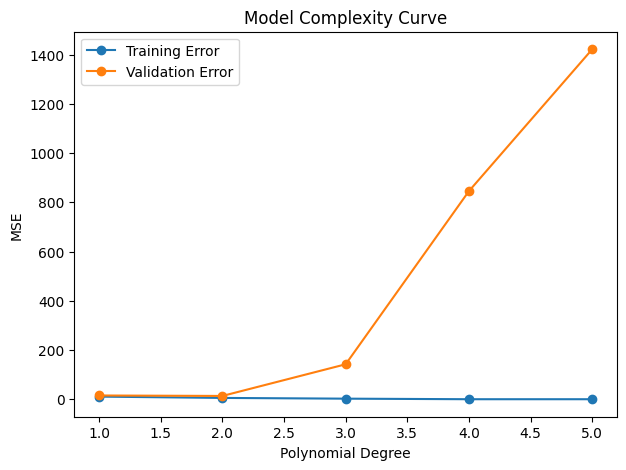

In [51]:
plt.figure(figsize=(7,5)) ## model complexity

plt.plot(degrees, train_errors, marker='o', label="Training Error")
plt.plot(degrees, val_errors, marker='o', label="Validation Error")

plt.xlabel("Polynomial Degree")
plt.ylabel("MSE")
plt.title("Model Complexity Curve")

plt.legend()
plt.show()

In [52]:
best_poly = PolynomialFeatures(degree=2) ##training model with the chosen degree=2

X_train_poly = best_poly.fit_transform(X_train_scaled)
X_test_poly = best_poly.transform(X_test_scaled)

best_model = LinearRegression()
best_model.fit(X_train_poly, y_train)

y_pred_poly = best_model.predict(X_test_poly)

In [53]:
mse_poly = mean_squared_error(y_test, y_pred_poly) ##calculate values for chosen degree=2
rmse_poly = np.sqrt(mse_poly)
mae_poly = mean_absolute_error(y_test, y_pred_poly)
r2_poly = r2_score(y_test, y_pred_poly)

print("MSE:", mse_poly)
print("RMSE:", rmse_poly)
print("MAE:", mae_poly)
print("R2:", r2_poly)

MSE: 6.237246217009352
RMSE: 2.497447940800639
MAE: 1.9169815828066916
R2: 0.8839936997505187


## KNN


Analyze a non-parametric regression model using KNN

In [54]:
from sklearn.neighbors import KNeighborsRegressor ##cheack with 20 K

k_values = range(1,21)

train_errors = []
val_errors = []

for k in k_values:

    knn = KNeighborsRegressor(n_neighbors=k)

    knn.fit(X_train_scaled, y_train)

    y_train_pred = knn.predict(X_train_scaled)
    y_val_pred = knn.predict(X_val_scaled)

    train_mse = mean_squared_error(y_train, y_train_pred)
    val_mse = mean_squared_error(y_val, y_val_pred)

    train_errors.append(train_mse)
    val_errors.append(val_mse)

    print(f"K={k}, Train MSE={train_mse:.3f}, Validation MSE={val_mse:.3f}")

K=1, Train MSE=0.000, Validation MSE=12.418
K=2, Train MSE=3.792, Validation MSE=12.078
K=3, Train MSE=4.915, Validation MSE=11.667
K=4, Train MSE=5.667, Validation MSE=10.751
K=5, Train MSE=5.861, Validation MSE=11.383
K=6, Train MSE=6.378, Validation MSE=11.798
K=7, Train MSE=6.514, Validation MSE=12.066
K=8, Train MSE=6.917, Validation MSE=11.672
K=9, Train MSE=7.343, Validation MSE=11.702
K=10, Train MSE=7.731, Validation MSE=11.854
K=11, Train MSE=8.068, Validation MSE=12.220
K=12, Train MSE=8.300, Validation MSE=12.186
K=13, Train MSE=8.742, Validation MSE=12.438
K=14, Train MSE=9.062, Validation MSE=12.836
K=15, Train MSE=9.332, Validation MSE=12.917
K=16, Train MSE=9.449, Validation MSE=12.882
K=17, Train MSE=9.569, Validation MSE=13.051
K=18, Train MSE=9.583, Validation MSE=13.132
K=19, Train MSE=9.623, Validation MSE=13.224
K=20, Train MSE=9.810, Validation MSE=13.472


In [55]:
best_k = k_values[np.argmin(val_errors)] ##finding best K

print("Best K:", best_k)

Best K: 4


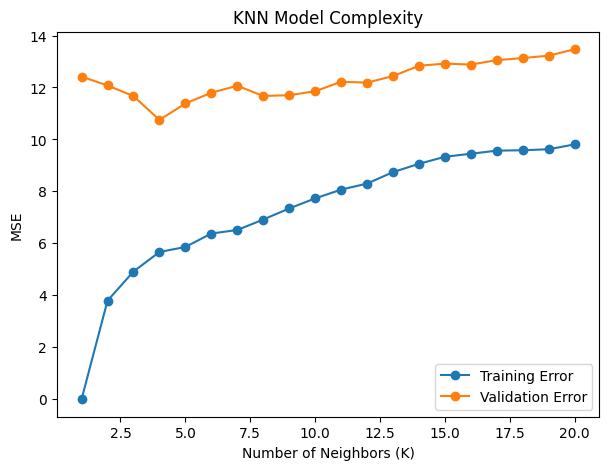

In [56]:
plt.figure(figsize=(7,5))

plt.plot(k_values, train_errors, marker='o', label="Training Error")
plt.plot(k_values, val_errors, marker='o', label="Validation Error")

plt.xlabel("Number of Neighbors (K)")
plt.ylabel("MSE")
plt.title("KNN Model Complexity")

plt.legend()
plt.show()

we can see that the best k is: k=4.

In [57]:
knn_model = KNeighborsRegressor(n_neighbors=best_k) ##train the model with k=4

knn_model.fit(X_train_scaled, y_train)

y_pred_knn = knn_model.predict(X_test_scaled)

In [58]:
mse_knn = mean_squared_error(y_test, y_pred_knn) ## calculate metrics
rmse_knn = np.sqrt(mse_knn)
mae_knn = mean_absolute_error(y_test, y_pred_knn)
r2_knn = r2_score(y_test, y_pred_knn)

print("KNN Regression Results")
print("Best K:", best_k)
print("MSE:", mse_knn)
print("RMSE:", rmse_knn)
print("MAE:", mae_knn)
print("R2:", r2_knn)

KNN Regression Results
Best K: 4
MSE: 6.247109374999997
RMSE: 2.499421808138834
MAE: 1.9974999999999994
R2: 0.8838102552579554


## Optimization Behavior

##Model Comparison and Discussion


After comparing the three models,the polynomial regression model with degree 2 was chosen as the final model.
This model provided the best tradeoff between accuracy and model complexity.

The linear regression model was simpler but slightly less accurate,while higher polynomial degrees
led to overfitting.The KNN model achieved similar performance but is less interpretable and
more computationally expensive.

Therefore,polynomial regression with degree 2 was selected as the final model.